In [1]:
# Impor library yang dibutuhkan
import pandas as pd
import numpy as np
from scipy import stats
import statsmodels.api as sm
import statsmodels.formula.api as smf
import seaborn as sns
import matplotlib.pyplot as plt

# Memastikan hasil dapat direproduksi
np.random.seed(42)

# Membuat data untuk 50 hari per kampanye
n_samples = 50
mean_A, mean_B, std_dev = 100, 108, 15
penjualan_A = np.random.normal(mean_A, std_dev, n_samples)
penjualan_B = np.random.normal(mean_B, std_dev, n_samples)

df = pd.DataFrame({
    'penjualan': np.concatenate([penjualan_A, penjualan_B]),
    'kampanye': ['A'] * n_samples + ['B'] * n_samples
})

,penjualan,kampanye
0,107.450712,A
1,97.926035,A
2,109.715328,A
3,122.845448,A
4,96.487699,A


In [2]:
print(df.head())

    penjualan kampanye
0  107.450712        A
1   97.926035        A
2  109.715328        A
3  122.845448        A
4   96.487699        A


## Pendekatan 1: Uji-t Sampel Independen

In [4]:
# Memisahkan data berdasarkan grup
grup_A = df[df['kampanye'] == 'A']['penjualan']
grup_B = df[df['kampanye'] == 'B']['penjualan']

# Menjalankan Uji-t
t_stat_ttest, p_value_ttest = stats.ttest_ind(grup_B, grup_A)

print(f"Hasil Uji-t: t-statistic = {t_stat_ttest:.4f}, p-value = {p_value_ttest:.4f}")

Hasil Uji-t: t-statistic = 4.2930, p-value = 0.0000


## Pendekatan 2: Membingkai Ulang Masalah dengan Regresi Linier

In [5]:
# Statsmodels akan secara otomatis menetapkan 'A' sebagai referensi (0).
model = smf.ols('penjualan ~ kampanye', data=df).fit()

# Menampilkan ringkasan hasil model
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:              penjualan   R-squared:                       0.158
Model:                            OLS   Adj. R-squared:                  0.150
Method:                 Least Squares   F-statistic:                     18.43
Date:                Wed, 05 Nov 2025   Prob (F-statistic):           4.15e-05
Time:                        11:51:40   Log-Likelihood:                -401.65
No. Observations:                 100   AIC:                             807.3
Df Residuals:                      98   BIC:                             812.5
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
Intercept        96.6179      1.919     50.356

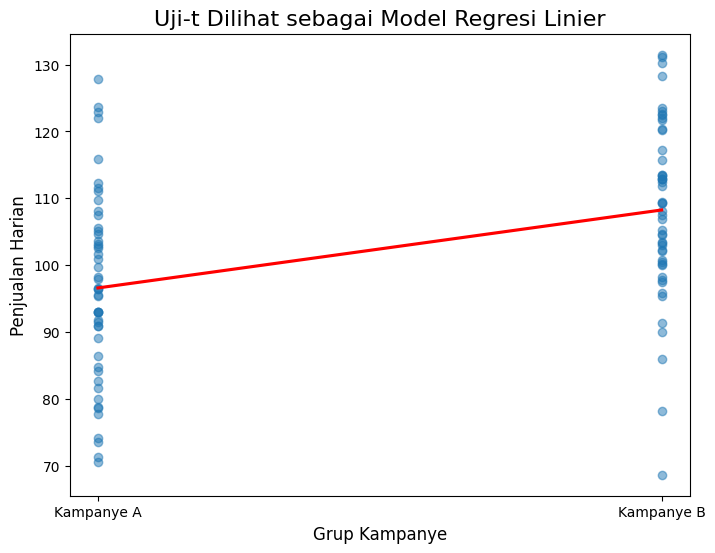

In [9]:
# Membuat plot regresi
plt.figure(figsize=(8, 6))
sns.regplot(x=df['kampanye'].apply(lambda x: 1 if x == 'B' else 0),
            y='penjualan', data=df, ci=None,
            line_kws={'color': 'red'}, scatter_kws={'alpha': 0.5})
plt.title('Uji-t Dilihat sebagai Model Regresi Linier', fontsize=16)
plt.xticks([0, 1], ['Kampanye A', 'Kampanye B'])
plt.xlabel('Grup Kampanye', fontsize=12)
plt.ylabel('Penjualan Harian', fontsize=12)

plt.savefig('1.webp', format='webp')
# -----------------------------------

plt.show()

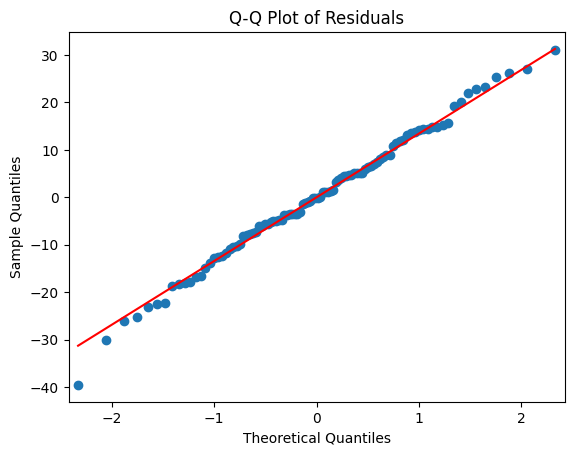

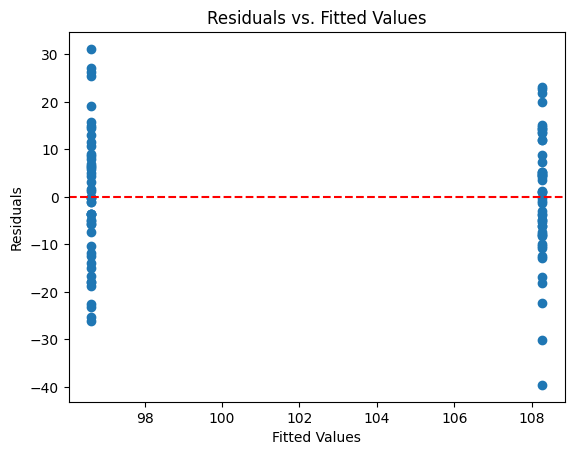

In [12]:
# 1. Cek Normalitas Residual dengan Q-Q Plot
sm.qqplot(model.resid, line='s')
plt.title('Q-Q Plot of Residuals')
plt.savefig('2.webp', format='webp')
plt.show()

# 2. Cek Homoskedastisitas
plt.scatter(model.fittedvalues, model.resid)
plt.axhline(y=0, color='red', linestyle='--')
plt.title('Residuals vs. Fitted Values')
plt.xlabel('Fitted Values')
plt.ylabel('Residuals')
plt.savefig('3.webp', format='webp')
plt.show()
